# 🏷️ Stage 2: Case Representation
## Sistem CBR Putusan Pengadilan - Pidana Umum Penggelapan

**Tujuan Notebook ini:**
- Mengekstrak metadata dari teks putusan (nomor perkara, pasal, nama terdakwa, dll)
- Menghitung fitur statistik teks
- Membuat ringkasan teks menggunakan TextRank sederhana
- Mengekstrak amar putusan
- Mengklasifikasikan berat hukuman
- Menyimpan representasi ke `data/processed/cases.csv`

**Konsep CBR:**
> Case Representation adalah bagaimana setiap kasus direpresentasikan dalam format yang dapat diproses komputer. Representasi yang baik menentukan kualitas retrieval.

---

In [ ]:
import sys, os
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from representation import (
    extract_metadata, extract_text_features, simple_textrank_summary,
    extract_amar_putusan, classify_hukuman, build_case_representation
)

print('✅ Library berhasil diimport!')

✅ Library berhasil diimport!


## Step 2.1: Load Data dari Stage 1

In [ ]:
# Load cleaned_cases.csv hasil dari Stage 1
CLEANED_CSV = Path('..') / 'data' / 'processed' / 'cleaned_cases.csv'
CASES_CSV   = Path('..') / 'data' / 'processed' / 'cases.csv'

df_raw = pd.read_csv(CLEANED_CSV, encoding='utf-8-sig')

print(f'Data dimuat: {len(df_raw)} kasus')
print(f'Kolom: {list(df_raw.columns)}')
df_raw.head(3)

Data dimuat: 106 kasus
Kolom: ['case_id', 'filename', 'cleaned_text']


,case_id,filename,cleaned_text
0,CASE_001,putusan_0372_pdt.g_2016_pa.wsp_20260617144938.pdf,a i s e n o d n i k i l b u p e a r i s g e n ...
1,CASE_002,putusan_1027_k_pid_2016_20260610214911.pdf,a i s e n o d n i k i l b u p e a r i s g e n ...
2,CASE_003,putusan_1031_k_pid_2013_20260610220650.pdf,a i s e n o d n i k i l b u p e a r i s g e n ...


## Step 2.2: Demo Ekstraksi Metadata

In [ ]:
# Demo ekstraksi metadata dari 1 kasus
contoh_teks = df_raw.iloc[0]['cleaned_text']

print('TEKS KASUS (200 karakter pertama):')
print('-' * 50)
print(contoh_teks[:200])

print('\nMETADATA YANG DIEKSTRAK:')
print('-' * 50)
metadata = extract_metadata(contoh_teks)
for key, val in metadata.items():
    print(f'  {key:20} : {val if val else "(tidak ditemukan)"}')

TEKS KASUS (200 karakter pertama):
--------------------------------------------------
a i s e n o d n i k i l b u p e a r i s g e n n o u d g n a i h k a i l m b u a p k e h a r a p u t u s a n i s nomor 372/pdt.g/2016/pa.wsp. m g e n n o demui keadilan berdasarkan ketuhanan yang maha 

METADATA YANG DIEKSTRAK:
--------------------------------------------------
  nomor_perkara        : no 372/pdt.g/2016/pa.wsp
  tanggal_putusan      : 2016-06-01
  pasal                : Pasal 82 KUHP
  nama_terdakwa        : (tidak ditemukan)
  nama_hakim           : (tidak ditemukan)


## Step 2.3: Demo Fitur Statistik

In [ ]:
# Demo fitur statistik
features = extract_text_features(contoh_teks)
print('FITUR STATISTIK:')
print('-' * 50)
for key, val in features.items():
    print(f'  {key:25} : {val}')

FITUR STATISTIK:
--------------------------------------------------
  jumlah_kata               : 6025
  jumlah_kalimat            : 108
  panjang_dokumen           : 28825


## Step 2.4: Demo TextRank Ringkasan

In [ ]:
# Demo TextRank summary
ringkasan = simple_textrank_summary(contoh_teks, n_sentences=3)

print('RINGKASAN FAKTA (TextRank - 3 kalimat):')
print('-' * 50)
print(ringkasan)

RINGKASAN FAKTA (TextRank - 3 kalimat):
--------------------------------------------------
bahwa, pemohnon yakin tidak ada lagi harapan untuk meneruskan rumah n tangga denugan termohon, karena tujuan perkawinan untuk membentuk rumaho tangga yang sakinah, mawaddah wa rahmah, sudah tidak terwujud d lagi, g sehingga sangat beralasan apabila permohonan ini dikabulkan; n a berdasarkan alasan-alasan tersebut pemohon mohon kepada bapak ketua i pe ngadilan agama watansoppeng cq majelis hakim yang m emeriksa dan h k mengadili perkara ini berkenan menjatuhkan putusan : a i primer: l m b 1.. membebankan biaya perkara sesuai dengan hukum yang berlaku; n n subsider: o jika muajelis hakim berpendapat lain, mohon putusan yang seadil-adilnya.. yaitu u a putusan yang dijatuhkan tanpa hadirnya termohon dapat dikabulkan sepanjang p k permohonan pemohon berdasarkan hukum dan beralasan, oleh karena itu majelis h hakim membebankan pemohon untuek membuktikan dalil-dalil permohonannya; a a menimbang, bahwra u

## Step 2.5: Demo Ekstraksi Amar Putusan

In [ ]:
# Demo amar putusan
amar = extract_amar_putusan(contoh_teks)

print('AMAR PUTUSAN:')
print('-' * 50)
print(amar[:300] if len(amar) > 300 else amar)

AMAR PUTUSAN:
--------------------------------------------------
mengadilid perkara tertentu, pada tingkat pertama dalam sidang majelis telah menjatuhankan putusan a perkara cerai talak, antara: i hpemohon, umur 34 tahun, pendidikan smp, agama isla k m, pekerjaan petani, bertempat tinggal di kabupaten soppeng, sebagai pemohon; a i l melawan m b termohon, umur 27 


## Step 2.6: Bangun Representasi Semua Kasus

In [ ]:
# Bangun representasi untuk semua kasus
print('Memproses semua kasus...')
df_cases = build_case_representation(
    str(CLEANED_CSV),
    str(CASES_CSV)
)

print(f'\n✅ Representasi selesai!')
print(f'Total kasus: {len(df_cases)}')
print(f'Kolom: {list(df_cases.columns)}')

2026-06-18 19:03:59,189 - INFO - Membaca data dari: ..\data\processed\cleaned_cases.csv
2026-06-18 19:03:59,237 - INFO - Memproses 106 kasus...


Memproses semua kasus...


2026-06-18 19:03:59,898 - INFO - Representasi kasus tersimpan: ..\data\processed\cases.csv



✅ Representasi selesai!
Total kasus: 106
Kolom: ['case_id', 'nomor_perkara', 'tanggal_putusan', 'pasal', 'nama_terdakwa', 'nama_hakim', 'jumlah_kata', 'jumlah_kalimat', 'panjang_dokumen', 'ringkasan_fakta', 'amar_putusan', 'kategori_hukuman', 'cleaned_text']


In [ ]:
# Preview kolom utama
df_cases[['case_id', 'pasal', 'kategori_hukuman', 'jumlah_kata', 'jumlah_kalimat']].head(10)

,case_id,pasal,kategori_hukuman,jumlah_kata,jumlah_kalimat
0,CASE_001,Pasal 82 KUHP,berat,6025,108
1,CASE_002,Pasal 55 KUHP,ringan,23884,708
2,CASE_003,Pasal 367 KUHP,ringan,11160,272
3,CASE_004,Pasal 64 KUHP,berat,9529,182
4,CASE_005,Pasal 374 KUHP,ringan,7538,198
5,CASE_006,Pasal 55 KUHP,ringan,4791,123
6,CASE_007,Pasal 372 KUHP,ringan,4333,75
7,CASE_008,Pasal 372 KUHP,ringan,4170,125
8,CASE_009,Pasal 65 KUHP,berat,11229,367
9,CASE_010,Pasal 488 KUHP,ringan,40814,1009


## Step 2.7: Visualisasi Representasi Kasus

D:\Temp\ipykernel_24624\1930738903.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1,1].boxplot(data_box, labels=categories, patch_artist=True)


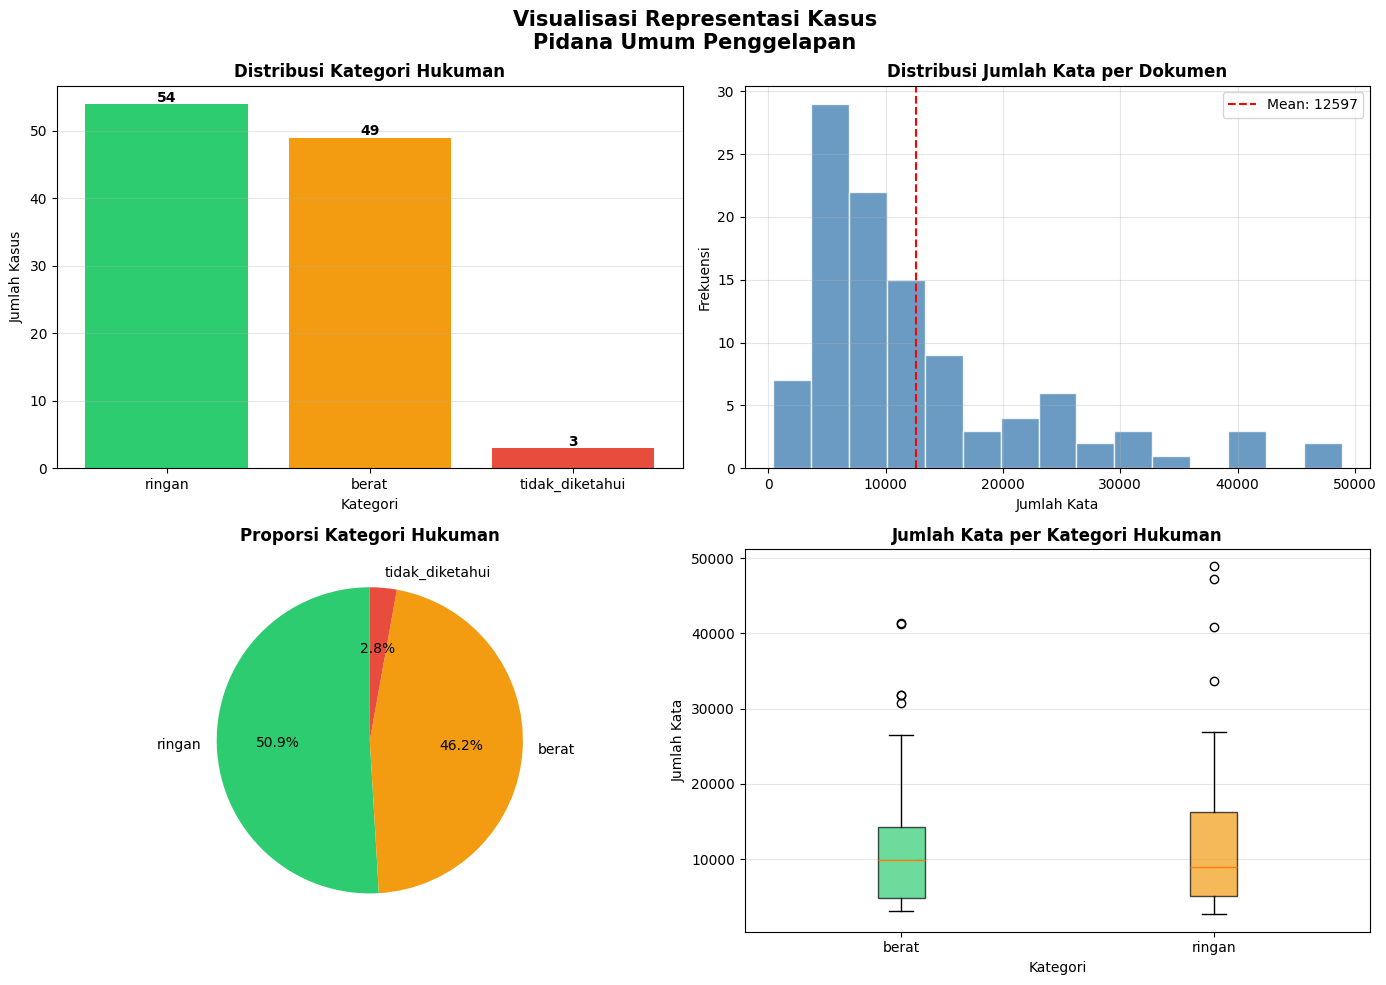

✅ Visualisasi disimpan: outputs/stage2_representasi.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Visualisasi Representasi Kasus\nPidana Umum Penggelapan', 
             fontsize=15, fontweight='bold')

# 1. Distribusi Kategori Hukuman
kategori_counts = df_cases['kategori_hukuman'].value_counts()
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#95a5a6']
axes[0,0].bar(kategori_counts.index, kategori_counts.values, color=colors[:len(kategori_counts)])
axes[0,0].set_title('Distribusi Kategori Hukuman', fontweight='bold')
axes[0,0].set_xlabel('Kategori')
axes[0,0].set_ylabel('Jumlah Kasus')
for i, v in enumerate(kategori_counts.values):
    axes[0,0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')
axes[0,0].grid(alpha=0.3, axis='y')

# 2. Distribusi Jumlah Kata
axes[0,1].hist(df_cases['jumlah_kata'], bins=15, color='steelblue', 
               edgecolor='white', alpha=0.8)
axes[0,1].set_title('Distribusi Jumlah Kata per Dokumen', fontweight='bold')
axes[0,1].set_xlabel('Jumlah Kata')
axes[0,1].set_ylabel('Frekuensi')
axes[0,1].axvline(df_cases['jumlah_kata'].mean(), color='red', linestyle='--',
                   label=f'Mean: {df_cases["jumlah_kata"].mean():.0f}')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# 3. Pie Chart Kategori Hukuman
axes[1,0].pie(kategori_counts.values, labels=kategori_counts.index,
               autopct='%1.1f%%', colors=colors[:len(kategori_counts)],
               startangle=90)
axes[1,0].set_title('Proporsi Kategori Hukuman', fontweight='bold')

# 4. Box plot jumlah kata per kategori
valid_df = df_cases[df_cases['kategori_hukuman'] != 'tidak_diketahui']
if len(valid_df) > 0:
    categories = valid_df['kategori_hukuman'].unique()
    data_box = [valid_df[valid_df['kategori_hukuman'] == cat]['jumlah_kata'].tolist() 
                for cat in categories]
    bp = axes[1,1].boxplot(data_box, labels=categories, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[1,1].set_title('Jumlah Kata per Kategori Hukuman', fontweight='bold')
    axes[1,1].set_xlabel('Kategori')
    axes[1,1].set_ylabel('Jumlah Kata')
    axes[1,1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../outputs/stage2_representasi.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualisasi disimpan: outputs/stage2_representasi.png')